In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
andrewmvd_liver_tumor_segmentation_path = kagglehub.dataset_download('andrewmvd/liver-tumor-segmentation')

print('Data source import complete.')


100%|██████████| 4.84G/4.84G [00:44<00:00, 117MB/s]

Extracting files...


Data source import complete.


In [ ]:
!pip install nibabel segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00


In [ ]:
import os
import nibabel as nib
import numpy as np
import cv2
import shutil
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp
import torch.optim as optim
import random
import time
import pandas as pd

In [ ]:
andrewmvd_liver_tumor_segmentation_path

'/root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5'

## data preprocessing
check dataset folders and make sure volumes match segmentation files

In [ ]:
ROOT_DIR = andrewmvd_liver_tumor_segmentation_path
print("ROOT_DIR:", ROOT_DIR)
print("\nContents of ROOT_DIR:")
for item in sorted(os.listdir(ROOT_DIR)):
    print(" -", item)


ROOT_DIR: /root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5

Contents of ROOT_DIR:
 - segmentations
 - volume_pt1
 - volume_pt2
 - volume_pt3
 - volume_pt4
 - volume_pt5


In [ ]:
VOLUME_DIRS = [
    os.path.join(ROOT_DIR, d)
    for d in os.listdir(ROOT_DIR)
    if d.startswith("volume_pt")
]

for vdir in sorted(VOLUME_DIRS):
    nii_files = [f for f in os.listdir(vdir) if f.endswith(".nii")]
    print(f"{os.path.basename(vdir)}: {len(nii_files)} volumes")
    print("  sample:", nii_files[:3])


volume_pt1: 11 volumes
  sample: ['volume-2.nii', 'volume-4.nii', 'volume-6.nii']
volume_pt2: 10 volumes
  sample: ['volume-11.nii', 'volume-19.nii', 'volume-12.nii']
volume_pt3: 10 volumes
  sample: ['volume-22.nii', 'volume-29.nii', 'volume-25.nii']
volume_pt4: 10 volumes
  sample: ['volume-40.nii', 'volume-31.nii', 'volume-35.nii']
volume_pt5: 10 volumes
  sample: ['volume-46.nii', 'volume-42.nii', 'volume-48.nii']


In [ ]:
SEG_DIR = os.path.join(ROOT_DIR, "segmentations")

seg_files = [f for f in os.listdir(SEG_DIR) if f.endswith(".nii")]
print(f"\nsegmentations: {len(seg_files)} files")
print("sample:", seg_files[:3])


segmentations: 131 files
sample: ['segmentation-97.nii', 'segmentation-117.nii', 'segmentation-46.nii']


In [ ]:
missing = []

for vdir in VOLUME_DIRS:
    for f in os.listdir(vdir):
        if not f.endswith(".nii"):
            continue

        idx = f.replace("volume-", "").replace(".nii", "")
        expected = f"segmentation-{idx}.nii"

        if expected not in seg_files:
            missing.append(idx)

len(missing) == 0:
    print("All volumes have matching segmentations")
else:
    print("Missing segmentations for volumes:", missing)

All volumes have matching segmentations


In [ ]:

SAMPLE_VOLUME = os.path.join(ROOT_DIR, "volume_pt1", os.listdir(os.path.join(ROOT_DIR, "volume_pt1"))[0])
idx = SAMPLE_VOLUME.split("volume-")[-1].replace(".nii", "")
SAMPLE_SEG = os.path.join(ROOT_DIR, "segmentations", f"segmentation-{idx}.nii")

print("Volume file:", SAMPLE_VOLUME)
print("Segmentation file:", SAMPLE_SEG)

vol = nib.load(SAMPLE_VOLUME).get_fdata()
seg = nib.load(SAMPLE_SEG).get_fdata()

print("\nVolume shape:", vol.shape)
print("Segmentation shape:", seg.shape)


Volume file: /root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5/volume_pt1/volume-2.nii
Segmentation file: /root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5/segmentations/segmentation-2.nii

Volume shape: (512, 512, 517)
Segmentation shape: (512, 512, 517)


In [ ]:
print("Unique labels in segmentation:", np.unique(seg))

Unique labels in segmentation: [0. 1. 2.]


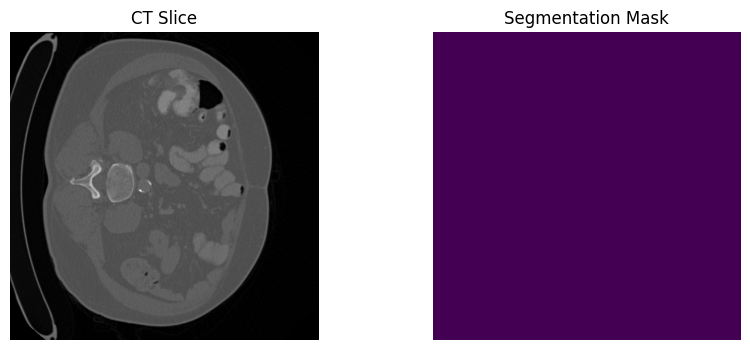

In [ ]:
z = vol.shape[2] // 2
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.axis("off")
plt.imshow(vol[:, :, z], cmap="gray")
plt.title("CT Slice")

plt.subplot(1,2,2)
plt.axis("off")
plt.imshow(seg[:, :, z])
plt.title("Segmentation Mask")
plt.show()


convert 3d ct volumes into 2d slices and keep only slices with annotations

In [ ]:
OUT_IMG = "data_2d/images"
OUT_MSK = "data_2d/masks"

os.makedirs(OUT_IMG, exist_ok=True)
os.makedirs(OUT_MSK, exist_ok=True)


def normalize_ct(img):
    img = np.clip(img, -100, 400)
    img = (img + 100) / 500.0
    img = (img * 255).astype(np.uint8)
    return img

total_saved = 0

for vol_dir in VOLUME_DIRS:
    print(f"\nProcessing {os.path.basename(vol_dir)}")

    for fname in tqdm(sorted(os.listdir(vol_dir))):
        if not fname.endswith(".nii"):
            continue

        idx = fname.replace("volume-", "").replace(".nii", "")
        vol_path = os.path.join(vol_dir, fname)
        seg_path = os.path.join(ROOT_DIR, "segmentations", f"segmentation-{idx}.nii")

        volume = nib.load(vol_path).get_fdata()
        seg = nib.load(seg_path).get_fdata()

        for z in range(volume.shape[2]):
            seg_slice = seg[:, :, z]


            if not np.any(seg_slice > 0):
                continue

            img_slice = normalize_ct(volume[:, :, z])
            seg_slice = seg_slice.astype(np.uint8)

            name = f"volume{idx}_slice{z:03d}.png"

            cv2.imwrite(os.path.join(OUT_IMG, name), img_slice)
            cv2.imwrite(os.path.join(OUT_MSK, name), seg_slice)

            total_saved += 1

print("\nTotal slices saved:", total_saved)



Processing volume_pt1


100%|██████████| 11/11 [00:32<00:00,  2.98s/it]



Processing volume_pt2


100%|██████████| 10/10 [00:37<00:00,  3.75s/it]



Processing volume_pt4


...


Processing volume_pt3


100%|██████████| 10/10 [00:25<00:00,  2.54s/it]



Processing volume_pt5


100%|██████████| 10/10 [00:10<00:00,  1.03s/it]


Total slices saved: 6802


In [ ]:
print("Images saved:", len(os.listdir("data_2d/images")))
print("Masks saved :", len(os.listdir("data_2d/masks")))


Images saved: 6802
Masks saved : 6802


Remove slices with very small liver regions to reduce noise

In [ ]:
OUT_IMG = "data_2d/images"
OUT_MSK  = "data_2d/masks"

DST_IMG = "data_2d_clean/images"
DST_MSK = "data_2d_clean/masks"

os.makedirs(DST_IMG, exist_ok=True)
os.makedirs(DST_MSK, exist_ok=True)

H, W = 512, 512
MIN_LIVER_PIXELS = int(0.01 * H * W)

kept = 0
removed = 0

for fname in tqdm(os.listdir(OUT_MSK)):
    mask = cv2.imread(os.path.join(OUT_MSK, fname), 0)

    liver_pixels = np.sum(mask == 1)

    if liver_pixels >= MIN_LIVER_PIXELS:
        shutil.move(os.path.join(OUT_IMG, fname), os.path.join(DST_IMG, fname))
        shutil.move(os.path.join(OUT_MSK, fname), os.path.join(DST_MSK, fname))
        kept += 1
    else:
        removed += 1
print(f"\nKept slices   : {kept}")
print(f"Removed slices: {removed}")

100%|██████████| 6802/6802 [00:11<00:00, 572.75it/s]


Kept slices   : 5836
Removed slices: 966


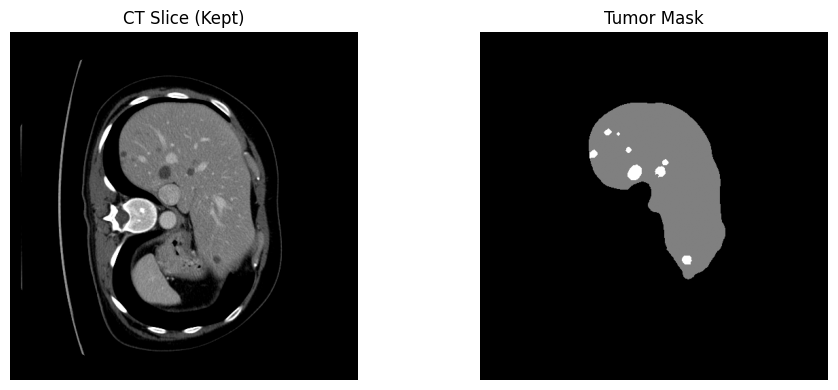

In [ ]:
sample_name = os.listdir(DST_IMG)[0]

img = cv2.imread(os.path.join(DST_IMG, sample_name), 0)
mask = cv2.imread(os.path.join(DST_MSK, sample_name), 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("CT Slice (Kept)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_DIR = "data_2d_clean/images"

volume_ids = set()

for fname in os.listdir(IMG_DIR):
    if fname.startswith("volume"):
        vid = fname.split("_")[0].replace("volume", "")
        volume_ids.add(vid)

volume_ids = sorted(list(volume_ids))
print("Total unique volumes:", len(volume_ids))
print("Sample volume IDs:", volume_ids[:10])


Total unique volumes: 51
Sample volume IDs: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17']


In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
volume_ids = list(volume_ids)
random.shuffle(volume_ids)

split_idx = int(0.8 * len(volume_ids))

train_vols = set(volume_ids[:split_idx])
val_vols   = set(volume_ids[split_idx:])

print("Train volumes:", len(train_vols))
print("Val volumes  :", len(val_vols))


Train volumes: 40
Val volumes  : 11


In [ ]:
for split in ["train", "val"]:
    os.makedirs(f"dataset/{split}/images", exist_ok=True)
    os.makedirs(f"dataset/{split}/masks", exist_ok=True)

In [ ]:
train_count = 0
val_count = 0

for fname in tqdm(os.listdir(DST_IMG)):
    vid = fname.split("_")[0].replace("volume", "")

    if vid in train_vols:
        dst = "train"
        train_count += 1
    elif vid in val_vols:
        dst = "val"
        val_count += 1
    else:
        continue

    shutil.copy(
        os.path.join(DST_IMG, fname),
        os.path.join(f"dataset/{dst}/images", fname)
    )
    shutil.copy(
        os.path.join(DST_MSK, fname),
        os.path.join(f"dataset/{dst}/masks", fname)
    )

print("\nTrain slices:", train_count)
print("Val slices  :", val_count)

100%|██████████| 5836/5836 [00:08<00:00, 709.52it/s] 


Train slices: 4590
Val slices  : 1246


In [ ]:
print("Train images:", len(os.listdir("dataset/train/images")))
print("Train masks :", len(os.listdir("dataset/train/masks")))
print("Val images  :", len(os.listdir("dataset/val/images")))
print("Val masks   :", len(os.listdir("dataset/val/masks")))

train_vols_check = set(
    f.split("_")[0] for f in os.listdir("dataset/train/images")
)
val_vols_check = set(
    f.split("_")[0] for f in os.listdir("dataset/val/images")
)

overlap = train_vols_check.intersection(val_vols_check)

print("Volume overlap between train & val:", overlap)

def check_labels(mask_dir):
    labels = set()
    for f in os.listdir(mask_dir):
        m = cv2.imread(os.path.join(mask_dir, f), 0)
        labels |= set(np.unique(m))
    return labels

print("Train labels:", check_labels("dataset/train/masks"))
print("Val labels  :", check_labels("dataset/val/masks"))



Train images: 4590
Train masks : 4590
Val images  : 1246
Val masks   : 1246
Volume overlap between train & val: set()
Train labels: {np.uint8(0), np.uint8(1), np.uint8(2)}
Val labels  : {np.uint8(0), np.uint8(1), np.uint8(2)}


## k-means segmentation 
we applied classical k-means clustering as a baseline segmentation method

In [ ]:
def kmeans(img, k=4, target_cluster=2):
    pixels = img.reshape(-1, 1).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, centers = cv2.kmeans(pixels, k, None, criteria, 5, cv2.KMEANS_RANDOM_CENTERS)
    labels = labels.reshape(img.shape)
    sorted_idx = np.argsort(centers.flatten())

    target_cluster = min(target_cluster, k-1)

    mask = (labels == sorted_idx[target_cluster]).astype(np.uint8) * 255
    return mask

In [27]:
def dice_coeff(pred, gt):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)
    intersection = np.sum(pred_bin * gt_bin)
    return 2 * intersection / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-6)


In [ ]:
def segment_and_evaluate(img, gt, sigma, erode1_iter, dilate_iter, erode2_iter, close_kernel_size, k=4, target_cluster=2, return_mask=False):
    rows, cols = img.shape
    X, Y = np.meshgrid(np.linspace(-1,1,cols), np.linspace(-1,1,rows))
    D = np.sqrt(X**2 + Y**2)

    vignette_mask = np.exp(-D**2 / (2*sigma**2))
    vertical_mask = np.ones((rows, cols))
    vertical_mask[rows//2:, :] = vignette_mask[rows//2:, :]
    img_vig = (img.astype(np.float32) * vertical_mask).astype(np.uint8)

    mask = kmeans(img_vig, k=k, target_cluster=target_cluster)

    kernel1 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    mask = cv2.erode(mask, kernel1, iterations=erode1_iter)
    kernel2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    mask = cv2.dilate(mask, kernel2, iterations=dilate_iter)
    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    mask = cv2.erode(mask, kernel3, iterations=erode2_iter)
    kernel4 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel_size, close_kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel4)

    if return_mask:
        return mask, dice_coeff(mask, gt)
    else:
        return dice_coeff(mask, gt)


## k-means tuning
searched for the best k-means and morphology parameters using dice score

In [28]:

param_space = {
    "sigma": [0.8, 0.9, 1.0, 1.1],
    "erode1_iter": [1,2],
    "dilate_iter": [1,2,3],
    "erode2_iter": [1,2,3],
    "close_kernel_size": [7, 9, 11],
    "k": [3, 4, 5],
    "target_cluster": [0,1, 2],
}


In [29]:

samples = os.listdir("data_2d_clean/images")[11:16]

best_dice = 0
best_params = None
all_combinations = list(itertools.product(*param_space.values()))

for values in tqdm(all_combinations, desc="Searching parameters"):
    params = dict(zip(param_space.keys(), values))
    dice_scores = []

    for sample in samples:
        img = cv2.imread(os.path.join("data_2d_clean/images", sample), 0)
        gt = cv2.imread(os.path.join("data_2d_clean/masks", sample), 0)

        mask, dice = segment_and_evaluate(img, gt,
            sigma=params['sigma'],
            erode1_iter=params['erode1_iter'],
            dilate_iter=params['dilate_iter'],
            erode2_iter=params['erode2_iter'],
            close_kernel_size=params['close_kernel_size'],
            k=params['k'],
            target_cluster=params['target_cluster'],
            return_mask=True
        )
        dice_scores.append(dice)

    mean_dice = np.mean(dice_scores)
    if mean_dice > best_dice:
        best_dice = mean_dice
        best_params = params

print("\nBest mean Dice:", best_dice)
print("Best parameters:", best_params)


Searching parameters: 100%|██████████| 1944/1944 [58:58<00:00,  1.82s/it]


Best mean Dice: 0.8349487674089549
Best parameters: {'sigma': 0.8, 'erode1_iter': 2, 'dilate_iter': 1, 'erode2_iter': 3, 'close_kernel_size': 7, 'k': 4, 'target_cluster': 2}


## k-means evaluation
we evaluated k-means on validation data using dice, iou, precision, recall, and time

In [30]:
def iou_score(pred, gt, eps=1e-7):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)
    intersection = np.sum(pred_bin * gt_bin)
    union = np.sum(pred_bin) + np.sum(gt_bin) - intersection
    return (intersection + eps) / (union + eps)


In [31]:
def precision_recall(pred, gt, eps=1e-7):
    pred_bin = (pred > 0).astype(np.uint8)
    gt_bin = (gt > 0).astype(np.uint8)
    tp = np.sum(pred_bin * gt_bin)
    fp = np.sum(pred_bin * (1 - gt_bin))
    fn = np.sum((1 - pred_bin) * gt_bin)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return precision, recall

In [32]:
KMEANS_RESULTS_DIR = "kmeans_results"
os.makedirs(KMEANS_RESULTS_DIR, exist_ok=True)

val_images = sorted(os.listdir("dataset/val/images"))
kmeans_results = {}
kmeans_times = []
for fname in tqdm(val_images, desc="K-means processing"):
    img = cv2.imread(os.path.join("dataset/val/images", fname), 0)
    gt = cv2.imread(os.path.join("dataset/val/masks", fname), 0)

    start_time = time.time()
    k_mask, k_dice = segment_and_evaluate(img, gt, **best_params, return_mask=True)
    kmeans_time = time.time() - start_time
    kmeans_times.append(kmeans_time)

    k_precision, k_recall = precision_recall(k_mask, gt)

    kmeans_results[fname] = {
        'mask': k_mask,
        'dice': k_dice,
        'iou': iou_score(k_mask, gt),
        'precision': k_precision,
        'recall': k_recall,
        'time': kmeans_time
    }

print(f"Computed k-means masks for {len(kmeans_results)} validation images")
print(f"Mean k-means time: {np.mean(kmeans_times):.4f}s ± {np.std(kmeans_times):.4f}s")

K-means processing: 100%|██████████| 1246/1246 [07:41<00:00,  2.70it/s]

Computed k-means masks for 1246 validation images
Mean k-means time: 0.3636s ± 0.0828s


class distribution

In [33]:
MASK_DIR = "data_2d_clean/masks"

tumor = 0
liver_only = 0

for f in os.listdir(MASK_DIR):
    mask = cv2.imread(os.path.join(MASK_DIR, f), 0)

    if np.any(mask == 2):
        tumor += 1
    else:
        liver_only += 1

total = tumor + liver_only

print(f"Tumor slices     : {tumor}")
print(f"Liver-only slices: {liver_only}")
print(f"Total slices     : {total}")
print(f"Tumor ratio      : {tumor/total:.3f}")

Tumor slices     : 2011
Liver-only slices: 3825
Total slices     : 5836
Tumor ratio      : 0.345


## dataset loader
we defined a pytorch dataset and applied data augmentation

In [ ]:
class LiTSDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        assert image is not None, f"Missing image {img_path}"
        assert mask is not None, f"Missing mask {mask_path}"

        image = image.astype(np.float32) / 255.0

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask  = augmented["mask"]

        image = torch.tensor(image).unsqueeze(0)
        mask  = torch.tensor(mask).long()

        return image, mask


In [35]:
train_tfms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

val_tfms = A.Compose([])


In [36]:
train_ds = LiTSDataset(
    image_dir="dataset/train/images",
    mask_dir="dataset/train/masks",
    transform=train_tfms
)

val_ds = LiTSDataset(
    image_dir="dataset/val/images",
    mask_dir="dataset/val/masks",
    transform=val_tfms
)

num_workers = 2
train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train batches: 2295
Val batches  : 623


## unet model
we initialized a unet with a resnet encoder for multiclass segmentation

In [37]:
import torch.nn as nn
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=3
).to(device)

print("Model ready on:", device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model ready on: cuda


## loss function
combined dice loss and cross entropy with class weighting

In [ ]:
dice_loss = smp.losses.DiceLoss(mode="multiclass")


class_weights = torch.tensor([0.2, 1.0, 4.0]).to(device)

ce_loss = nn.CrossEntropyLoss(weight=class_weights)

def loss_fn(preds, targets):
    return dice_loss(preds, targets) + ce_loss(preds, targets)


In [39]:
model.eval()

images, masks = next(iter(train_loader))
images = images.to(device)
masks  = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    loss = loss_fn(outputs, masks)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Mask shape  :", masks.shape)
print("Loss value  :", loss.item())


Input shape : torch.Size([2, 1, 512, 512])
Output shape: torch.Size([2, 3, 512, 512])
Mask shape  : torch.Size([2, 512, 512])
Loss value  : 1.6928579807281494


In [40]:

for param in model.encoder.parameters():
    param.requires_grad = False

print("Encoder frozen.")


Encoder frozen.


In [41]:

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

In [42]:
def dice_score(preds, targets, eps=1e-7):
    preds = torch.argmax(preds, dim=1)

    dice = []
    for cls in [1, 2]:
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice.append((2 * intersection + eps) / (union + eps))

    return sum(dice) / len(dice)


In [43]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()
def train_one_epoch(model, loader, optimizer, loss_fn, device, epoch_pbar=None):
    model.train()
    total_loss = 0

    for batch_idx, (images, masks) in enumerate(loader):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = loss_fn(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if epoch_pbar and batch_idx % 10 == 0:
            epoch_pbar.set_postfix({
                'Batch': f'{batch_idx}/{len(loader)}',
                'Loss': f'{loss.item():.4f}',
                'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })

    return total_loss / len(loader)


def validate(model, loader, loss_fn, device, epoch_pbar=None):
    model.eval()
    total_loss = 0
    total_dice = 0

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(loader):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, masks)
            total_loss += loss.item()
            total_dice += dice_score(outputs, masks).item()

            if epoch_pbar and batch_idx % 10 == 0:
                epoch_pbar.set_postfix({
                    'Val Batch': f'{batch_idx}/{len(loader)}',
                    'Val Loss': f'{loss.item():.4f}',
                    'Val Dice': f'{dice_score(outputs, masks).item():.4f}'
                })

    return total_loss / len(loader), total_dice / len(loader)


/tmp/ipython-input-3289994026.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## training strategy
trained the model in two phases: frozen encoder then full fine-tuning

In [44]:
EPOCHS_PHASE1 = 2
phase_pbar = tqdm(total=EPOCHS_PHASE1, desc="Phase 1", position=0, leave=True)

for epoch in range(EPOCHS_PHASE1):
    phase_pbar.set_description(f"Phase 1 - Epoch {epoch+1}/{EPOCHS_PHASE1}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device, phase_pbar)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    val_loss, val_dice = validate(model, val_loader, loss_fn, device, phase_pbar)

    phase_pbar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Val Loss': f'{val_loss:.4f}',
        'Val Dice': f'{val_dice:.4f}'
    })

    print(f"\n[Epoch {epoch+1}/{EPOCHS_PHASE1}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    phase_pbar.update(1)
phase_pbar.close()
print("Phase 1 complete!")

if torch.cuda.is_available():


Phase 1 - Epoch 1/2:   0%|          | 0/2 [00:00<?, ?it/s]/tmp/ipython-input-3289994026.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Phase 1 - Epoch 2/2:  50%|█████     | 1/2 [02:07<02:07, 127.31s/it, Batch=0/2295, Loss=0.0555, LR=1.00e-03]             


[Epoch 1/2] Train Loss: 0.3133 | Val Loss: 0.5793 | Val Dice: 0.6199


Phase 1 - Epoch 2/2: 100%|██████████| 2/2 [04:16<00:00, 128.01s/it, Train Loss=0.2128, Val Loss=0.5668, Val Dice=0.6023]


[Epoch 2/2] Train Loss: 0.2128 | Val Loss: 0.5668 | Val Dice: 0.6023
Phase 1 complete!


In [45]:
for param in model.encoder.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

In [46]:
best_val_dice = 0
patience = 3
patience_counter = 0

EPOCHS_PHASE2 = 12

phase2_pbar = tqdm(total=EPOCHS_PHASE2, desc="Phase 2", position=0, leave=True)

for epoch in range(EPOCHS_PHASE2):
    phase2_pbar.set_description(f"Phase 2 - Epoch {epoch+1}/{EPOCHS_PHASE2}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device, phase2_pbar)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    val_loss, val_dice = validate(model, val_loader, loss_fn, device, phase2_pbar)

    scheduler.step(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        phase2_pbar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Val Dice': f'{val_dice:.4f} ✓',
            'Best': f'{best_val_dice:.4f}'
        })
    else:
        patience_counter += 1
        phase2_pbar.set_postfix({
            'Train Loss': f'{train_loss:.4f}',
            'Val Dice': f'{val_dice:.4f}',
            'No imp': f'{patience_counter}/{patience}'
        })

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        print(f"Best validation Dice: {best_val_dice:.4f}")
        break

    phase2_pbar.update(1)

phase2_pbar.close()


Phase 2 - Epoch 1/12:   0%|          | 0/12 [00:00<?, ?it/s]/tmp/ipython-input-3289994026.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Phase 2 - Epoch 11/12:  83%|████████▎ | 10/12 [35:51<07:10, 215.16s/it, Train Loss=0.0931, Val Dice=0.6849, No imp=3/3]

In [47]:
def dice_per_class(preds, targets, eps=1e-7):
    preds = torch.argmax(preds, dim=1)

    scores = {}
    for cls, name in [(1, "liver"), (2, "tumor")]:
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        scores[name] = ((2 * intersection + eps) / (union + eps)).item()

    return scores


## unet evaluation
evaluated unet performance on validation data

In [ ]:
UNET_RESULTS_DIR = "unet_results"
os.makedirs(UNET_RESULTS_DIR, exist_ok=True)

unet_results = {}
unet_times = []
unet_memory = []

model.eval()
with torch.no_grad():
    for fname in tqdm(val_images, desc="U-Net processing"):
        img = cv2.imread(os.path.join("dataset/val/images", fname), 0)
        gt = cv2.imread(os.path.join("dataset/val/masks", fname), 0)

        img_t = torch.tensor(img.astype(np.float32)/255.0).unsqueeze(0).unsqueeze(0).to(device)

        start_time = time.time()
        output = model(img_t)
        unet_time = time.time() - start_time
        unet_times.append(unet_time)

        pred = torch.argmax(output, dim=1).cpu().numpy()[0]

        u_precision, u_recall = precision_recall(pred, gt)

        unet_results[fname] = {
            'mask': pred,
            'dice': dice_coeff(pred, gt),
            'iou': iou_score(pred, gt),
            'precision': u_precision,
            'recall': u_recall,
            'time': unet_time
        }

print(f"Computed U-Net predictions for {len(unet_results)} validation images")
print(f"Mean U-Net time: {np.mean(unet_times):.4f}s ± {np.std(unet_times):.4f}s")

U-Net processing: 100%|██████████| 1246/1246 [00:29<00:00, 42.86it/s]

Computed U-Net predictions for 1246 validation images
Mean U-Net time: 0.0061s ± 0.0018s


In [49]:
def colorize_mask(mask):
    h, w = mask.shape
    colored = np.zeros((h, w, 3), dtype=np.uint8)

    colored[mask == 1] = [0, 255, 0]
    colored[mask == 2] = [255, 0, 0]

    return colored


## model comparison
compared k-means and unet results numerically and visually

In [58]:
kmeans_dice_vals = [kmeans_results[f]['dice'] for f in val_images]
kmeans_iou_vals = [kmeans_results[f]['iou'] for f in val_images]
kmeans_precision_vals = [kmeans_results[f]['precision'] for f in val_images]
kmeans_recall_vals = [kmeans_results[f]['recall'] for f in val_images]
kmeans_time_vals = [kmeans_results[f]['time'] for f in val_images]

unet_dice_vals = [unet_results[f]['dice'] for f in val_images]
unet_iou_vals = [unet_results[f]['iou'] for f in val_images]
unet_precision_vals = [unet_results[f]['precision'] for f in val_images]
unet_recall_vals = [unet_results[f]['recall'] for f in val_images]
unet_time_vals = [unet_results[f]['time'] for f in val_images]

comparison_data = {
    'Metric': ['Dice Score', 'IoU', 'Precision', 'Recall', 'Time per image (s)'],
    'K-means': [
        f"{np.mean(kmeans_dice_vals):.3f} ± {np.std(kmeans_dice_vals):.3f}",
        f"{np.mean(kmeans_iou_vals):.3f} ± {np.std(kmeans_iou_vals):.3f}",
        f"{np.mean(kmeans_precision_vals):.3f} ± {np.std(kmeans_precision_vals):.3f}",
        f"{np.mean(kmeans_recall_vals):.3f} ± {np.std(kmeans_recall_vals):.3f}",
        f"{np.mean(kmeans_time_vals):.4f}"
    ],
    'U-Net': [
        f"{np.mean(unet_dice_vals):.3f} ± {np.std(unet_dice_vals):.3f}",
        f"{np.mean(unet_iou_vals):.3f} ± {np.std(unet_iou_vals):.3f}",
        f"{np.mean(unet_precision_vals):.3f} ± {np.std(unet_precision_vals):.3f}",
        f"{np.mean(unet_recall_vals):.3f} ± {np.std(unet_recall_vals):.3f}",
        f"{np.mean(unet_time_vals):.4f}"
    ]
}

df = pd.DataFrame(comparison_data)
print(df.to_string(index=False))

            Metric       K-means         U-Net
        Dice Score 0.554 ± 0.301 0.944 ± 0.084
               IoU 0.438 ± 0.271 0.902 ± 0.100
         Precision 0.601 ± 0.293 0.930 ± 0.083
            Recall 0.582 ± 0.334 0.965 ± 0.093
Time per image (s)        0.3636        0.0061


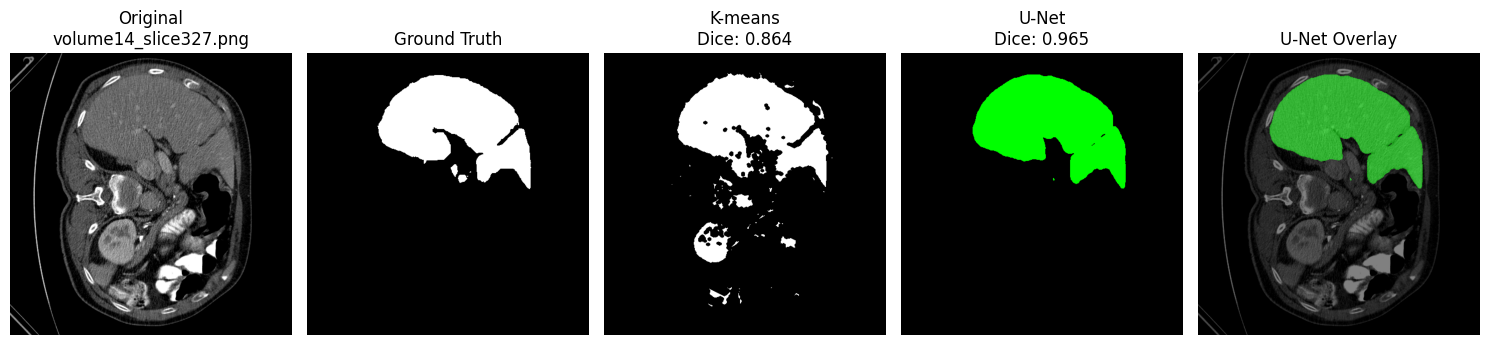

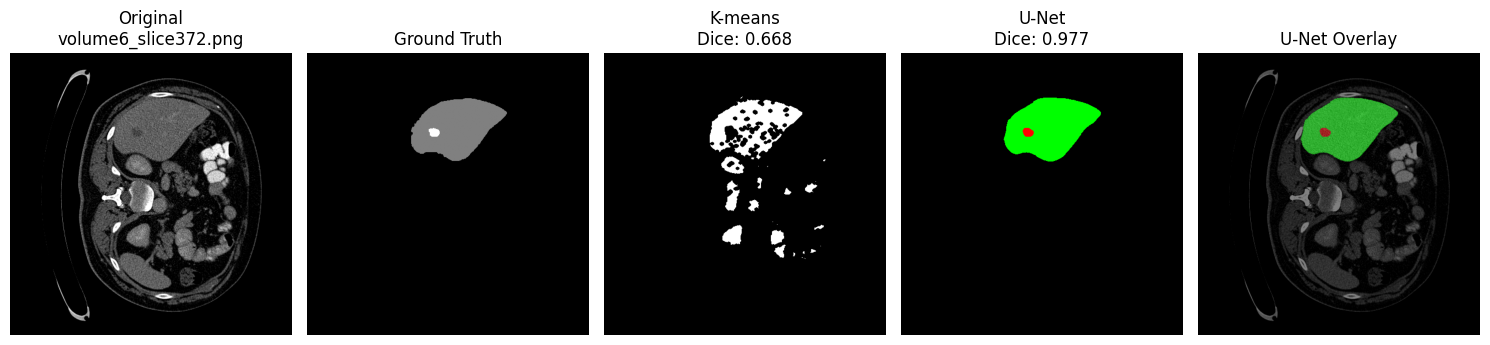

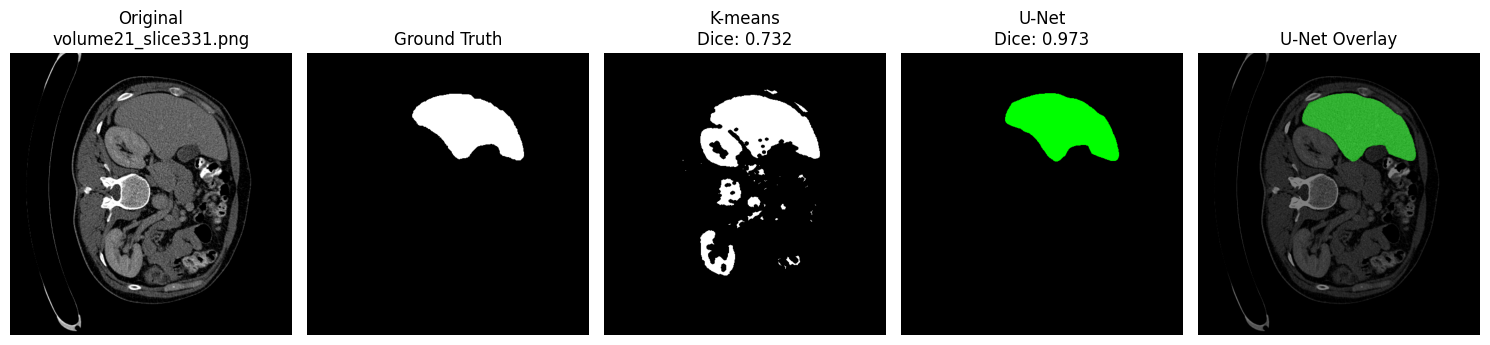

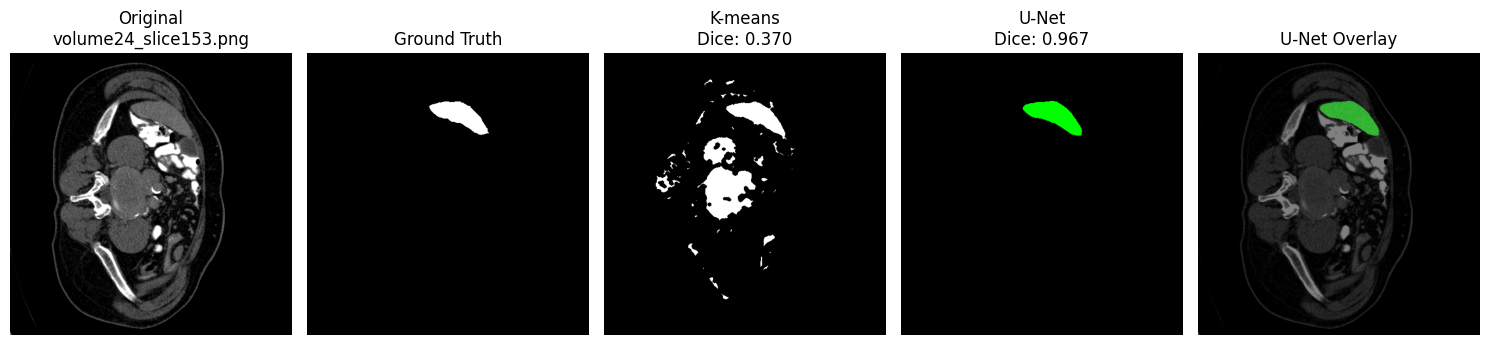

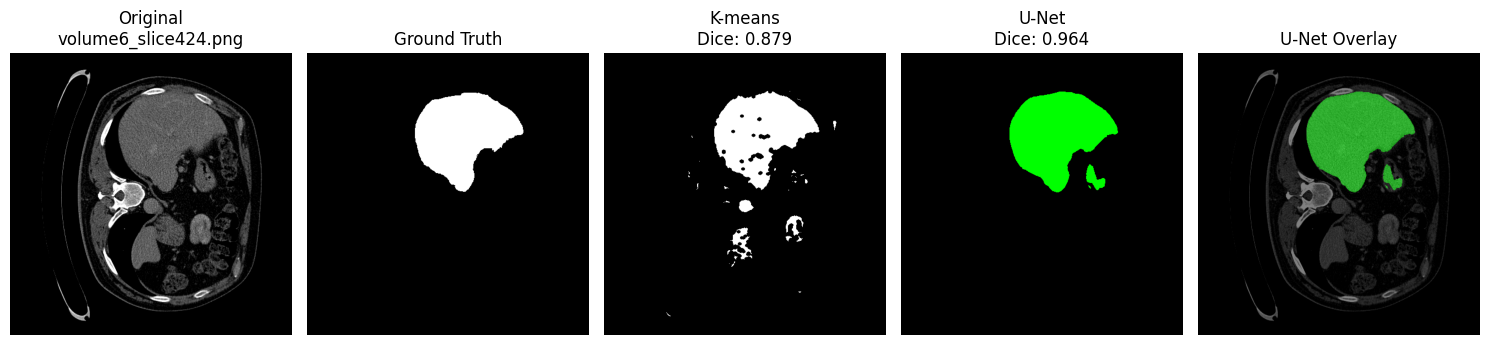

In [59]:
sample_indices = random.sample(range(len(val_images)), min(5, len(val_images)))

for i, idx in enumerate(sample_indices):
    fname = val_images[idx]
    img = cv2.imread(os.path.join("dataset/val/images", fname), 0)
    gt = cv2.imread(os.path.join("dataset/val/masks", fname), 0)

    k_mask = kmeans_results[fname]['mask']
    unet_mask = unet_results[fname]['mask']

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original\n{fname}")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(gt, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(k_mask, cmap='gray')
    plt.title(f"K-means\nDice: {kmeans_results[fname]['dice']:.3f}")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(colorize_mask(unet_mask))
    plt.title(f"U-Net\nDice: {unet_results[fname]['dice']:.3f}")
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.imshow(img, cmap='gray')
    plt.imshow(colorize_mask(unet_mask), alpha=0.5)
    plt.title("U-Net Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()